In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('dataset\heart_2020_cleaned.csv\heart_2020_cleaned.csv')
df.shape


(319795, 18)

# 전처리

In [54]:
df_sample = df.copy()


df_sample['Diabetic'] = df_sample['Diabetic'].map({
    'Yes': 'Yes',
    'Yes (during pregnancy)': 'Yes',
    'No': 'No',
    'No, borderline diabetes': 'No'
})

d = {
    "Yes"  : 1,
    "No"   : 0
}

d_sex = {
    "Female" : 0,
    "Male" : 1
}



df_sample['HeartDisease'] = df_sample['HeartDisease'].map(d)
df_sample['Smoking'] = df_sample['Smoking'].map(d)
df_sample['AlcoholDrinking'] = df_sample['AlcoholDrinking'].map(d)
df_sample['Stroke'] = df_sample['Stroke'].map(d)
df_sample['DiffWalking'] = df_sample['DiffWalking'].map(d)
df_sample['PhysicalActivity'] = df_sample['PhysicalActivity'].map(d)
df_sample['Asthma'] = df_sample['Asthma'].map(d)
df_sample['KidneyDisease'] = df_sample['KidneyDisease'].map(d)
df_sample['SkinCancer'] = df_sample['SkinCancer'].map(d)
df_sample['Diabetic'] = df_sample['Diabetic'].map(d)

df_sample['Sex'] = df_sample['Sex'].map(d_sex)

age_order = ['18-24', '25-29', '30-34', '35-39', '40-44',
             '45-49', '50-54', '55-59', '60-64', '65-69',
             '70-74', '75-79', '80 or older']

health_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']
df_sample['AgeCategory'] = df_sample['AgeCategory'].map({v: i for i, v in enumerate(age_order)})
df_sample['GenHealth'] = df_sample['GenHealth'].map({v: i for i, v in enumerate(health_order)})

# 다중공선성 문제로 선형 모델 사용시 따로 제거 필요
# df_sample.drop("SleepTime",axis =1 ,inplace = True)
# df_sample.drop("GenHealth",axis =1 ,inplace = True)

Race_dummies = pd.get_dummies(df_sample['Race'], prefix='Race',dtype = int)
Race_dummies.drop('Race_White', axis=1, inplace=True)

df_preprocessed= pd.concat([df_sample, Race_dummies], axis=1)
df_preprocessed.drop(['Race'], axis=1, inplace=True)


In [55]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 22 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   HeartDisease                         319795 non-null  int64  
 1   BMI                                  319795 non-null  float64
 2   Smoking                              319795 non-null  int64  
 3   AlcoholDrinking                      319795 non-null  int64  
 4   Stroke                               319795 non-null  int64  
 5   PhysicalHealth                       319795 non-null  float64
 6   MentalHealth                         319795 non-null  float64
 7   DiffWalking                          319795 non-null  int64  
 8   Sex                                  319795 non-null  int64  
 9   AgeCategory                          319795 non-null  int64  
 10  Diabetic                             319795 non-null  int64  
 11  PhysicalActiv

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_preprocessed.drop(columns=['HeartDisease','GenHealth'],axis = 1)  # 타깃 제외
vif_df = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_df)

                               Variable        VIF
0                                   BMI  13.949978
1                               Smoking   1.818588
2                       AlcoholDrinking   1.098325
3                                Stroke   1.097091
4                        PhysicalHealth   1.592414
5                          MentalHealth   1.427623
6                           DiffWalking   1.625203
7                                   Sex   1.956479
8                           AgeCategory   5.378977
9                              Diabetic   1.302159
10                     PhysicalActivity   4.416132
11                            SleepTime  15.095058
12                               Asthma   1.201451
13                        KidneyDisease   1.096068
14                           SkinCancer   1.203485
15  Race_American Indian/Alaskan Native   1.027361
16                           Race_Asian   1.040894
17                           Race_Black   1.120832
18                        Race_

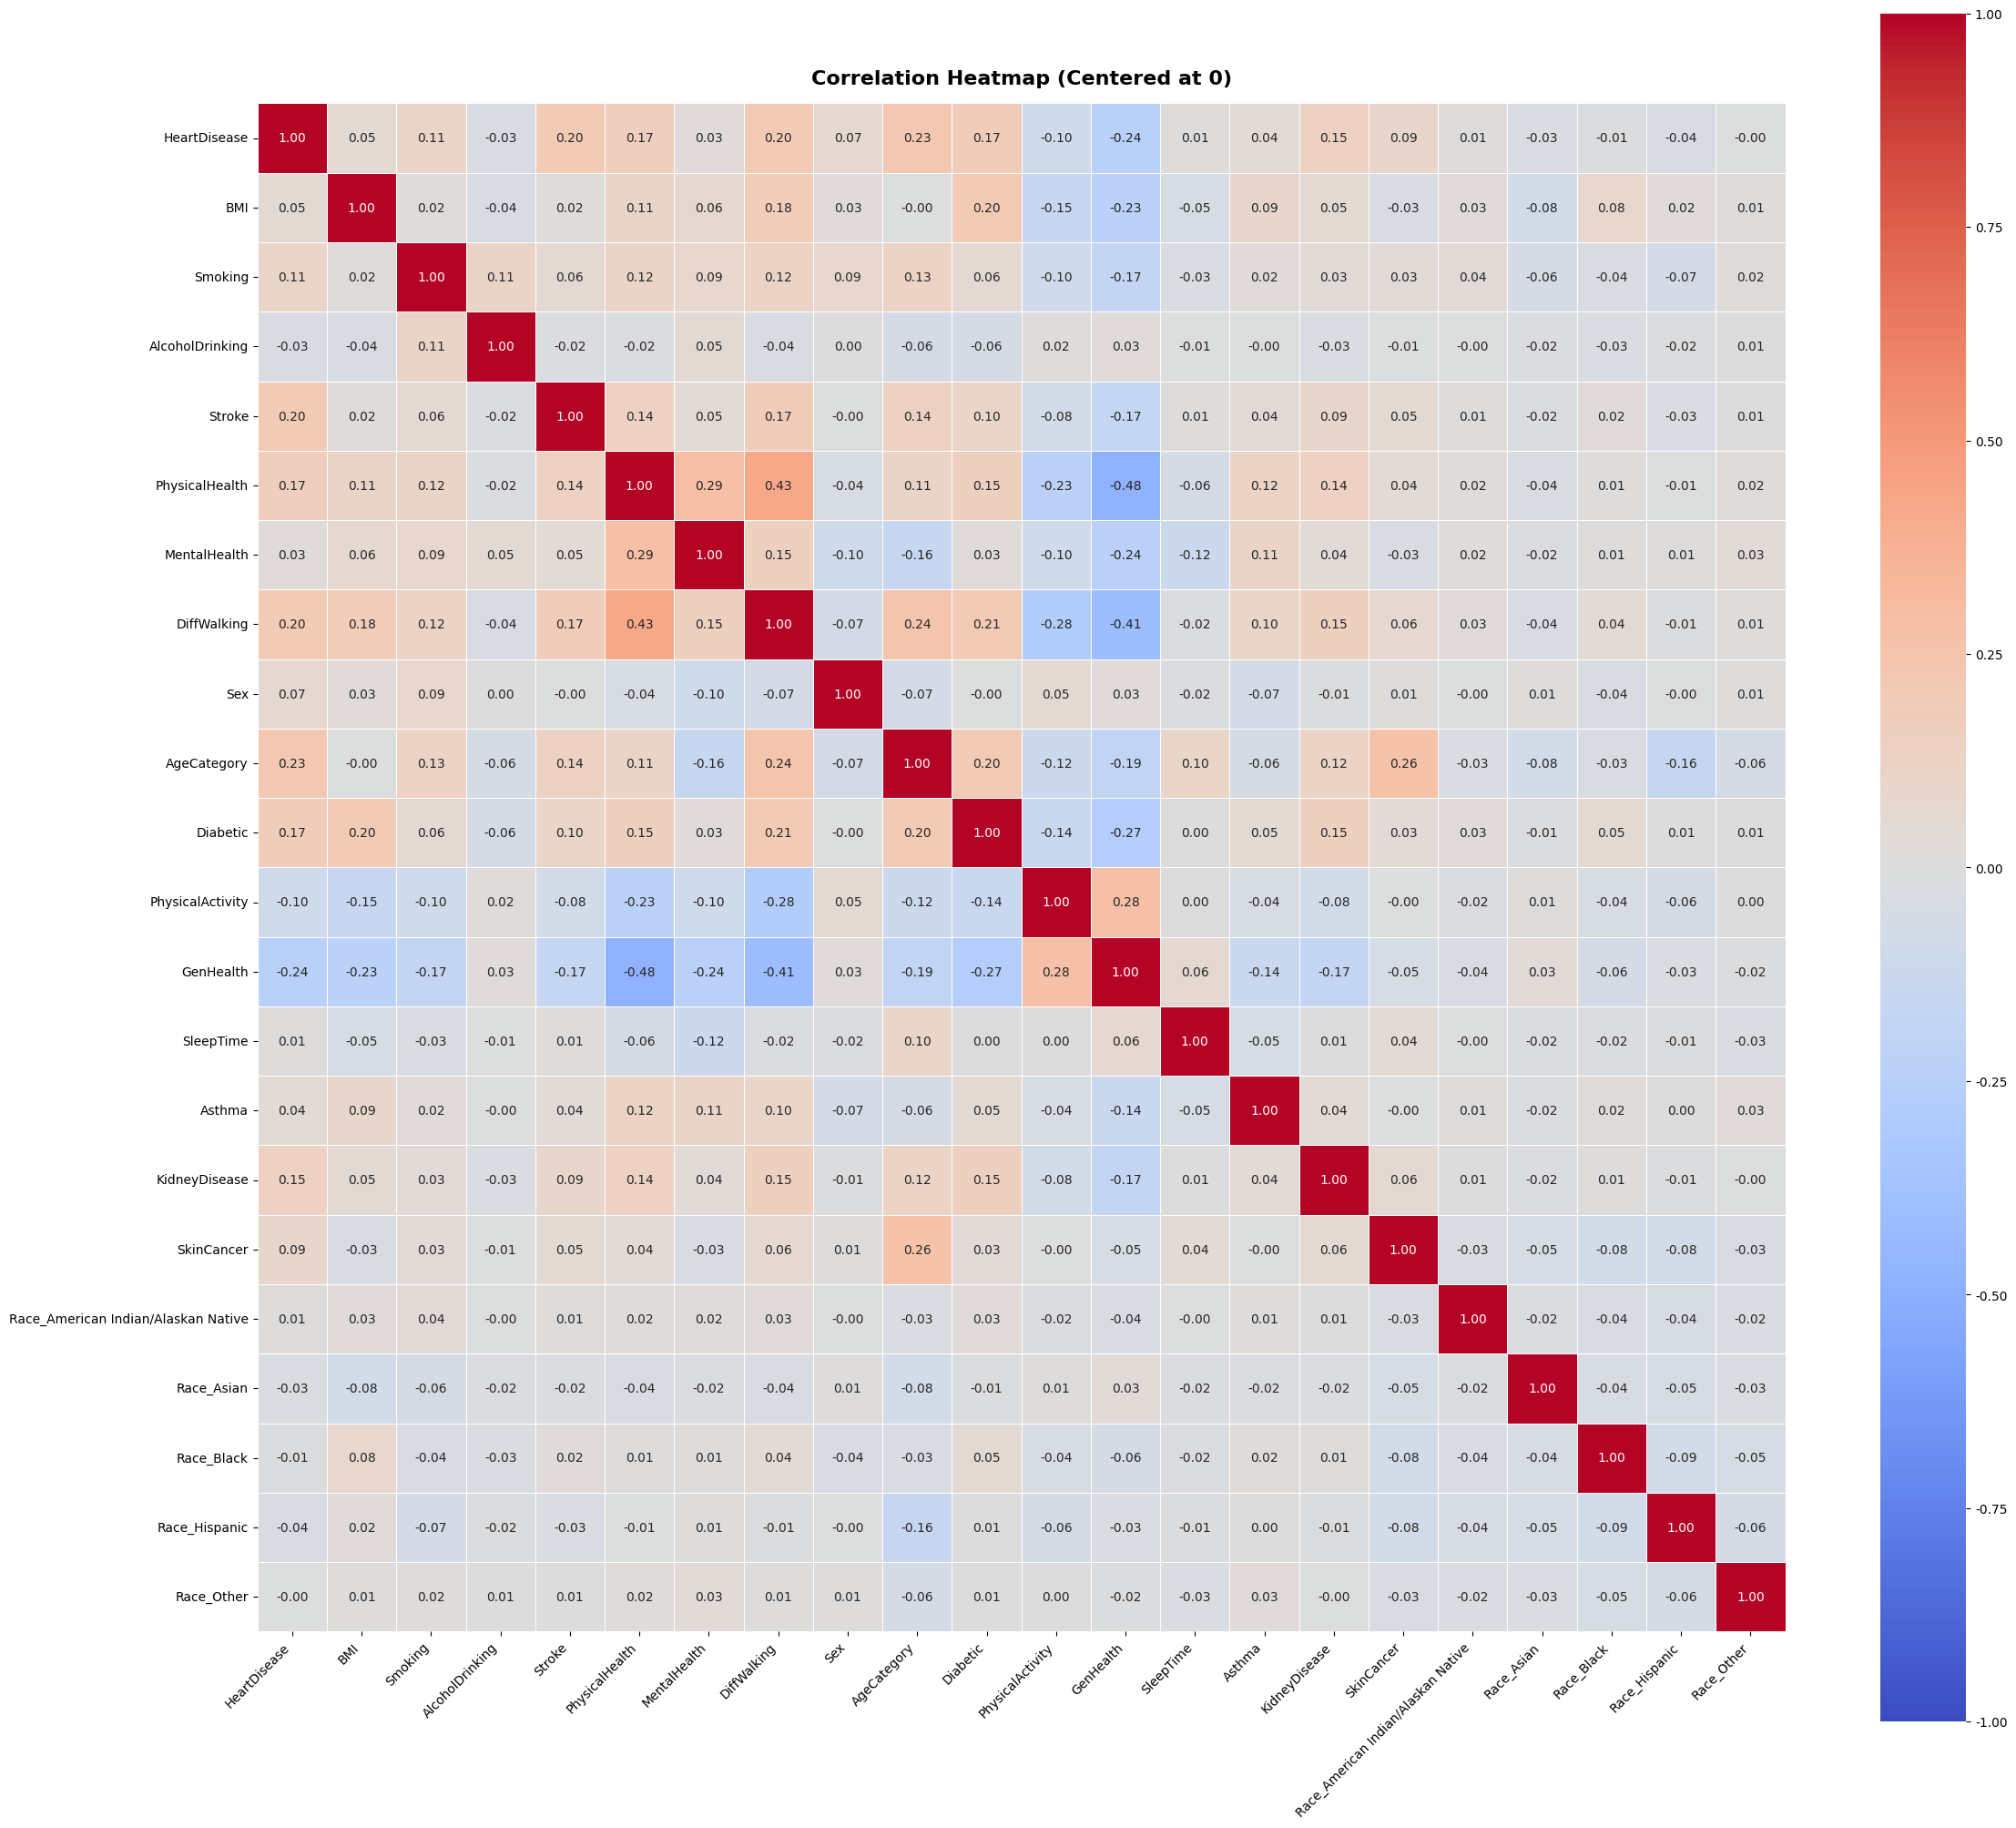

In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2️⃣ 상관행렬 계산
corr = df_preprocessed.corr()

# 3️⃣ 히트맵 시각화 (0을 중심으로)
plt.figure(figsize=(24, 24))
sns.heatmap(
    corr,
    cmap='coolwarm',        # 🔵 음의 상관 / 🔴 양의 상관
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    square=True,
    center=0,               # ✅ 색상 중심을 0으로
    vmin=-1, vmax=1         # ✅ 색상 범위를 -1 ~ +1로 고정
)

plt.title('Correlation Heatmap (Centered at 0)', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [59]:
df_preprocessed.to_csv('dataset/heart_preprocessed.csv', index=False, encoding='utf-8-sig')

In [ ]:
# 'Race' 범주 중 'White' 제거 (drop_first=True 효과)
# 'Diabetic' Yes,No 이진화

array(['White', 'Black', 'Asian', 'American Indian/Alaskan Native',
       'Other', 'Hispanic'], dtype=object)